In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

2026-05-24 15:32:14.380223: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 15:32:14.554713: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 15:32:17.145235: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 1. CNN Architecture Understanding & Modification

Output Shapes and Calculations:
1. Output size after the first Conv2D: For a 28×28 input with a 3×3 kernel and 32 filters, the output shape is (26, 26, 32).  
2. Output size after the first MaxPooling: A 2×2 pooling window halves the spatial dimensions, resulting in an output shape of (13, 13, 32).


Modified Model Code:

In [3]:
modified_model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    # Added new Conv2D layer
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'), 
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    # Added Dropout before the final dense layer
    tf.keras.layers.Dropout(0.3), 
    tf.keras.layers.Dense(10, activation='softmax')
])

modified_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

Explanations:
1. Why pooling is used: It is primarily used to reduce the spatial dimensions of the feature maps, which subsequently reduces the computational load and the number of parameters.  
2. Why ReLU is preferred: The Rectified Linear Unit (ReLU) introduces non-linearity into the network. This is crucial because it allows the model to learn and represent complex patterns within the data.

# 2. CNN Implementation on MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training with Adam optimizer...
Epoch 1/5


2026-04-29 21:48:20.036615: I external/local_xla/xla/service/service.cc:163] XLA service 0x71dd5800cd30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-29 21:48:20.036723: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-04-29 21:48:20.072597: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-29 21:48:20.236682: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2026-04-29 21:48:20.277575: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-29 21:48:21.

  42/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3488 - loss: 1.9436

I0000 00:00:1777481303.725000   27249 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9510 - loss: 0.1586 - val_accuracy: 0.9819 - val_loss: 0.0597
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9848 - loss: 0.0493 - val_accuracy: 0.9870 - val_loss: 0.0429
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9889 - loss: 0.0342 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9875 - val_loss: 0.0454
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9939 - loss: 0.0190 - val_accuracy: 0.9886 - val_loss: 0.0442

Training with SGD optimizer...
Epoch 1/5


2026-04-29 21:49:05.186275: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-29 21:49:06.027729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_343', 240 bytes spill stores, 240 bytes spill loads



1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8090 - loss: 0.6219 - val_accuracy: 0.9298 - val_loss: 0.2266
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9455 - loss: 0.1798 - val_accuracy: 0.9599 - val_loss: 0.1350
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9622 - loss: 0.1219 - val_accuracy: 0.9697 - val_loss: 0.1041
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9703 - loss: 0.0964 - val_accuracy: 0.9712 - val_loss: 0.0913
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9743 - loss: 0.0818 - val_accuracy: 0.9744 - val_loss: 0.0883

Test Accuracy (Adam): 0.9891
Test Accuracy (SGD): 0.9758


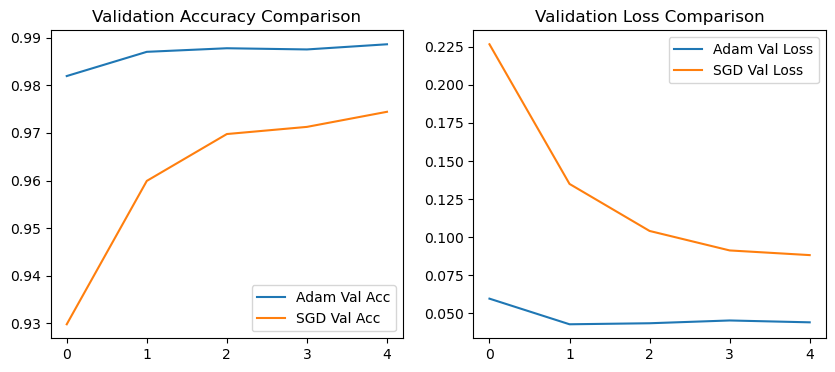

In [4]:
# --- 1. Load and Preprocess Data ---
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape to include the channel dimension (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# --- 2. Function to Build Base CNN ---
def build_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# --- 3. Train and Evaluate with Adam ---
model_adam = build_model()
model_adam.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training with Adam optimizer...")
history_adam = model_adam.fit(x_train, y_train, epochs=5, validation_split=0.2)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

# --- 4. Train and Evaluate with SGD ---
model_sgd = build_model()
model_sgd.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\nTraining with SGD optimizer...")
history_sgd = model_sgd.fit(x_train, y_train, epochs=5, validation_split=0.2)
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)

# --- 5. Output and Plotting ---
print(f"\nTest Accuracy (Adam): {adam_acc:.4f}")
print(f"Test Accuracy (SGD): {sgd_acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['val_accuracy'], label='Adam Val Acc')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Acc')
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

Why Adam Performed Better
1. Faster Convergence: In the Validation Accuracy Comparison plot, the Adam curve (blue) starts much higher and plateaus quickly. It reached over 98% accuracy in the very first epoch, while SGD (orange) started significantly lower at ~93% and took all five epochs to approach the 97% mark.
2. Lower Loss: The Validation Loss Comparison shows that Adam maintained a much lower and more stable loss throughout the training process compared to SGD.
3. Adaptive Learning Rates: Technically, Adam is more efficient because it calculates individual adaptive learning rates for different parameters. It uses estimates of both the first and second moments of the gradients to adapt the learning rate, allowing it to navigate the loss landscape more effectively than standard SGD, which uses a single fixed learning rate for all updates.

# 3. Effect of Pooling on Feature Maps

Given the initial matrix:
$$
\begin{bmatrix}
4 & 0 & -2 & 4 \\
3 & 1 & 0 & 2 \\
1 & 0 & 1 & 1 \\
4 & 6 & 5 & 1
\end{bmatrix}
$$

**1. Apply ReLU Activation:**
ReLU replaces all negative values with zero, mathematically represented as $f(x)=max(0,x)$.
$$
\text{ReLU Output} = \begin{bmatrix}
4 & 0 & 0 & 4 \\
3 & 1 & 0 & 2 \\
1 & 0 & 1 & 1 \\
4 & 6 & 5 & 1
\end{bmatrix}
$$

**2. Apply Pooling ($2\times2$, stride=2) on the ReLU Output:**

* **Max Pooling** (Takes the highest value in each $2\times2$ block):
    * Top-Left: $\max(4,0,3,1) = 4$
    * Top-Right: $\max(0,4,0,2) = 4$
    * Bottom-Left: $\max(1,0,4,6) = 6$
    * Bottom-Right: $\max(1,1,5,1) = 5$
    $$
    \text{Max Pool Output} = \begin{bmatrix}
    4 & 4 \\
    6 & 5
    \end{bmatrix}
    $$

* **Average Pooling** (Takes the average of each $2\times2$ block):
    * Top-Left: $(4+0+3+1)/4 = 2$
    * Top-Right: $(0+4+0+2)/4 = 1.5$
    * Bottom-Left: $(1+0+4+6)/4 = 2.75$
    * Bottom-Right: $(1+1+5+1)/4 = 2$
    $$
    \text{Avg Pool Output} = \begin{bmatrix}
    2 & 1.5 \\
    2.75 & 2
    \end{bmatrix}
    $$

**Explanation:**
* **Preserves strongest features:** Max pooling preserves the strongest features because it explicitly selects the maximum activation (the most prominent signal) from the local receptive field.
* **Smooths information:** Average pooling smooths information by calculating the mean of the patch, providing a more generalized, less sharp representation of the local features.

# 4. CNN Performance Improvement

Training regularized model...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8993 - loss: 0.3243 - val_accuracy: 0.9812 - val_loss: 0.0611
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9592 - loss: 0.1414 - val_accuracy: 0.9849 - val_loss: 0.0537
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9676 - loss: 0.1088 - val_accuracy: 0.9865 - val_loss: 0.0586
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9745 - loss: 0.0900 - val_accuracy: 0.9858 - val_loss: 0.0534
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9782 - loss: 0.0746 - val_accuracy: 0.9880 - val_loss: 0.0469


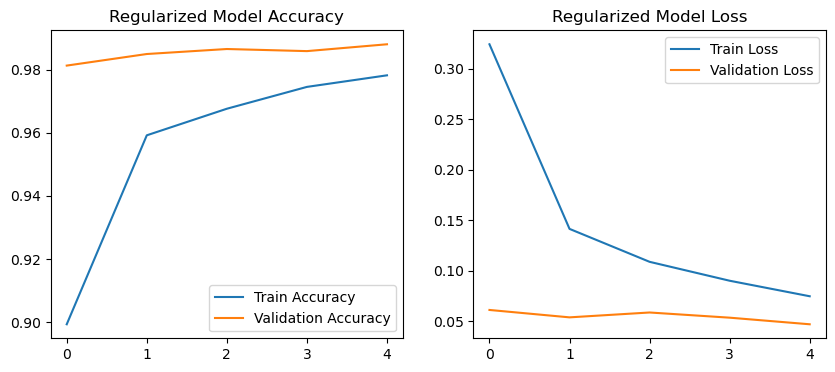

In [5]:
# Using the previously loaded x_train, y_train, x_test, y_test

def build_regularized_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(), # Added Batch Normalization
        tf.keras.layers.MaxPooling2D((2,2)),
        
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5), # Added Dropout
        tf.keras.layers.Dense(10, activation='softmax')
    ])

reg_model = build_regularized_model()
reg_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training regularized model...")
history_reg = reg_model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)

# Plotting Accuracy and Loss Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Validation Accuracy')
plt.title("Regularized Model Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title("Regularized Model Loss")
plt.legend()
plt.show()

Why does dropout help?
1. Prevents Overfitting: Dropout is a regularization technique used to address overfitting, which occurs when a model shows high training accuracy but low validation accuracy.  
2. Reduces Neuron Co-adaptation: By randomly "dropping out" or deactivating a fraction of neurons during each training step, the network is forced to learn more robust, distributed representations.  
3. Improves Generalization: Because no single neuron can rely on the presence of another specific neuron, the model learns redundant features that generalize better to unseen validation data.  
4. Observed Result: The validation accuracy (orange line) remains consistently high and even exceeds the training accuracy, indicating that the model has successfully avoided overfitting and is generalizing effectively.

What happens if dropout is too high?
1. Underfitting: If the dropout rate is set too high (e.g., 0.8 or 0.9), the network loses too much information and capacity during the training phase.  
2. Failure to Learn: The model will struggle to capture the underlying patterns in the training data, leading to a significant drop in both training and validation accuracy.  
3. Slow Convergence: The training process becomes inefficient because the network essentially lacks enough active "brain power" to minimize the loss function effectively.

# 5. CNN Layer-wise Output Interpretation

**Layer Roles:**
1. Input: Defines the incoming shape of the image data, passing the raw pixel values into the network.
2. Conv (Convolution): Applies filters across the image to extract and learn spatial hierarchies of features like edges, textures, or shapes.
3. ReLU: Introduces non-linearity to the network, deciding which feature maps are activated by zeroing out negative values.
4. Pool (Pooling): Downsamples the feature maps to reduce spatial dimensions, lowering computational requirements and controlling overfitting.
5. Flatten: Unrolls the 2D matrices from the previous layers into a single, continuous 1D vector.
6. Dense (Fully Connected): Learns the complex relationships between the flattened extracted features to map them to the final output labels.

**Computations based on Input ($28\times28\times1$):**
1. Output after Conv: Applying $32$ filters of $(3\times3)$ with stride $=1$ to a $28\times28$ image: $(28 - 3) / 1 + 1 = 26$. The shape becomes `(26, 26, 32)`.
2. Output after Pooling: Applying a $(2\times2)$ pool halves the spatial dimensions: $26 / 2 = 13$. The shape becomes `(13, 13, 32)`.
3. Size after Flatten: The flattening step multiplies all dimensions together: $13 \times 13 \times 32 = 5408$. The shape becomes a 1D vector of size `(5408,)`.

**Explanations:**
1. Why Flatten is required: The 2D feature maps must be converted into a 1D vector before they can be processed by dense layers. Dense layers are standard artificial neural network layers that expect one-dimensional input arrays.
2. What happens if Flatten is skipped: If skipped, the dense layer will receive multi-dimensional data (tensors). This will throw a dimensionality/shape error during model compilation or execution because standard Dense layers lack the architecture to process spatial (2D/3D) data directly.